# E5 — LoRA on a Matrix, Not a Model

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Count, exactly, how many numbers a dense weight update costs and how many a **rank-*r*** update costs
- Use the **SVD** to compute the *best possible* rank-*r* approximation of a real 512×512 transform, and read the error-vs-rank curve honestly
- Fit `ΔW = B A` from **data** with alternating least squares — the situation an optimizer is actually in, because it never sees `ΔW`
- Prove to yourself, with `np.linalg.matrix_rank`, why a "full" update trained on *n* examples was **already** a rank-*n* update — and what that means for choosing *r*

## 🔗 Where this fits

**Builds on:** Unit 1 lesson 02 *"Matrix Operations for ML"* — a matrix product `B @ A` and the shapes that make it legal is the entire mechanism here. Unit 1 lesson 03 *"Eigenvalues and Eigenvectors"* — you already truncated a spectrum to keep the directions that carry the variance; this notebook does the same thing to a **rectangular-style** decomposition instead of a symmetric one. Unit 1 lesson 06 *"Transformation Matrices and Orthogonal Basis Sets"* — the SVD hands you two orthogonal bases, one on each side of the transform. Unit 1 lesson 07 *"Eigenvalue Analysis on Large-Dimensional Matrices"* — truncating a large spectrum instead of computing all of it.

Most directly: lesson 08 *"Experimenting with ML Model Parameters"* ends with a **State of the field (2026)** box that names LoRA and says "the update is confined to a low-dimensional subspace, and what you tune is its rank, its direction and its norm." **This notebook is that paragraph, run.**

**A prerequisite we borrow early:** the singular value decomposition is taught properly in **Unit 4 lesson 04 `04_svd_implementation.ipynb`**. Here we use `np.linalg.svd` as a tool and take exactly one property from it on trust — stated and cited in Part 3.

**Used later in:** Course 08 (AIAT 122) — Unit 3 lesson 05 *"BERT fine-tuning"* and Unit 4, where "fine-tune a pretrained model" stops being a black box. Course 12 (AIAT 126) — Unit 3 *"Model Development"*, where the question "do we fine-tune, and how much of the model?" becomes a project decision with a budget attached.

## 🌍 Why this matters: the cheapest sentence in modern ML

In June 2021 Hu, Shen, Wallis, Allen-Zhu, Li, Wang, Wang and Chen published *LoRA: Low-Rank Adaptation of Large Language Models* ([arXiv:2106.09685](https://arxiv.org/abs/2106.09685)). Their abstract states the result plainly:

> "Compared to GPT-3 175B fine-tuned with Adam, LoRA can reduce the number of trainable parameters by **10,000 times** and the GPU memory requirement by **3 times**. LoRA performs on-par or better than fine-tuning in model quality on RoBERTa, DeBERTa, GPT-2, and GPT-3."

**That is the named, checkable case.** 175 billion parameters divided by 10,000 is 17.5 million trainable numbers — a model you could not fine-tune on any single machine became a model you could adapt on one. The whole idea is one line of linear algebra: freeze the pretrained matrix `W₀`, and instead of learning a full update `ΔW`, learn `ΔW = B A` where `B` is *tall and thin* and `A` is *short and wide*. Five years later LoRA is still the default parameter-efficient method, and QLoRA ([arXiv:2305.14314](https://arxiv.org/abs/2305.14314)) pushed the same trick onto a 4-bit frozen base so a 65B model fine-tunes on one 48 GB GPU.

**What goes wrong without this lesson.** People treat "rank" as a magic hyperparameter copied from a blog post — `r=8` because someone else used `r=8`. They cannot answer the two questions that decide it: *how much of the transform can rank r represent at all?* and *how much of it can I actually recover from the examples I have?* Those are a linear-algebra question and a statistics question, and this notebook separates them.

**The honest part.** You will see, on a real matrix, that low rank is **not** free: single-digit ranks leave a large fraction of this transform unrepresented, and you will read the exact price off a table you compute. And then you will see the fact that rescues LoRA anyway — a fact about *your dataset*, not about the matrix.

## 📥 Inputs & 📤 Outputs

**Inputs:** the quiz, project, case-study and assessment markdown under the twelve `Course NN/` folders of this repository — real course prose, already on disk (the README index pages are skipped; they are navigation, not writing). No downloads, no API keys, no network, no GPU. From that text we build two real objects: a matrix of document vectors `X`, and a 512×512 transform `ΔW` whose entries are **positive pointwise mutual information** between terms. Nothing here is `np.random`-generated data; the only random numbers in the notebook are the *initial values* of a factor matrix (the same place LoRA itself uses randomness) and one fixed-seed train/test split.

**Outputs:** a parameter-count table; the singular-value spectrum of a real 512×512 transform; an Eckart–Young error-vs-rank table and chart; a from-data fit of `B A` by alternating least squares; a sweep of held-out error over *(training-set size n, rank r)* with the measured rank of every dense solution; and one comparison in which 196,608 extra parameters buy nothing at all.

## Part 1: The arithmetic that motivates everything

A single square weight matrix of side 512 holds 512 × 512 = 262,144 numbers. A Transformer has hundreds of matrices like it. Full fine-tuning asks the optimizer to move **every one** of those numbers, and to store a gradient and two Adam moments for each.

LoRA asks a smaller question. Keep `W₀` frozen. Add `ΔW = B A`, with `B` of shape (512 × r) and `A` of shape (r × 512). The forward pass becomes `x W₀ + x B A` — one extra matrix product, no change to the output shape. The number of trainable values is now `r · (512 + 512) = 1024 r`.

Before running anything, look at what that costs.

In [1]:
# WHAT: count trainable numbers for a dense 512x512 update versus a rank-r factorisation B @ A.
# WHY:  every claim in this notebook is a trade between this column and an error column. Fix the
#       parameter arithmetic in your head first, so that later you are only judging quality.
import numpy as np
import pandas as pd

D = 512                                   # both sides of the square weight matrix we adapt
DENSE_PARAMS = D * D                      # a full update: one trainable number per entry

RANKS = [1, 2, 4, 8, 16, 32, 64, 128, 256]

rows = []
for r in RANKS:
    lora = r * (D + D)                    # B is (D x r) and A is (r x D): r*D + r*D numbers
    rows.append({
        "rank r": r,
        "B shape": f"{D}x{r}",
        "A shape": f"{r}x{D}",
        "trainable": lora,
        "% of dense": lora / DENSE_PARAMS,
        "x smaller": DENSE_PARAMS / lora,
    })

param_table = pd.DataFrame(rows)
print(f"Dense update on one {D}x{D} matrix: {DENSE_PARAMS:,} trainable numbers\n")
print(param_table.to_string(index=False,
                            formatters={"% of dense": "{:.2%}".format,
                                        "trainable": "{:,}".format,
                                        "x smaller": "{:.0f}x".format}))
print("\nBreak-even: a rank-r factorisation stops saving anything at r = D/2 =", D // 2)

Dense update on one 512x512 matrix: 262,144 trainable numbers

 rank r B shape A shape trainable % of dense x smaller
      1   512x1   1x512     1,024      0.39%      256x
      2   512x2   2x512     2,048      0.78%      128x
      4   512x4   4x512     4,096      1.56%       64x
      8   512x8   8x512     8,192      3.12%       32x
     16  512x16  16x512    16,384      6.25%       16x
     32  512x32  32x512    32,768     12.50%        8x
     64  512x64  64x512    65,536     25.00%        4x
    128 512x128 128x512   131,072     50.00%        2x
    256 512x256 256x512   262,144    100.00%        1x

Break-even: a rank-r factorisation stops saving anything at r = D/2 = 256


Two things are already visible. The saving is **linear in r**, so halving the rank halves the cost — there is no cliff to fall off. And the factorisation stops paying at `r = 256`: above that you are storing more numbers than the dense matrix you replaced. Every useful rank lives in the left half of that table.

But a parameter count is not an argument. The question is whether a rank-*r* matrix can *do the job*.

## Part 2: A real 512×512 transform to adapt to

We need a genuine target — not a matrix of random numbers, which would be low-rank in no interesting way and would teach nothing.

So we build one from this repository's own text. Every non-README `.md` file under `Course 01/` … `Course 12/` is split into heading-delimited sections. From those sections we take the 512 most frequent terms (after English stop-word removal) and compute, for each pair of terms *(i, j)*, their **positive pointwise mutual information**:

$$\Delta W_{ij} = \max\left(0,\ \log \frac{P(i, j)}{P(i)\,P(j)}\right)$$

This is a real, named operator. `x @ ΔW` takes a document's term vector and pushes it toward terms that *co-occur* with the ones it already contains — query expansion, the operator underneath latent semantic analysis, and the same object word2vec was later shown to be implicitly factorising. Treat it as the update we want to install on top of a frozen base: `W₀ = I` leaves the document alone; the adapter adds the corpus-specific expansion. That is exactly LoRA's shape, with the base map chosen to be as boring as possible so all the attention falls on `ΔW`.

In [2]:
# WHAT: load every course markdown file, cut it into sections, and build two real matrices:
#       X (documents x 512 terms) and dW (512 x 512 term-term PPMI) - the transform we must approximate.
# WHY:  a target matrix made with np.random would have a flat spectrum and every conclusion below would
#       be an artefact of the random number generator. Real text has real structure; that is the point.
import re
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer


def find_repo_root(start: Path) -> Path:
    """Walk up until we find the folder that holds the twelve course directories."""
    for parent in [start, *start.parents]:
        if (parent / "Course 01").is_dir() and (parent / "Course 12").is_dir():
            return parent
    raise RuntimeError(f"Could not locate the repository root starting from {start}")


REPO = find_repo_root(Path.cwd())
# Skip the README index pages: they are navigation, not prose, and they are edited whenever the
# course structure changes - which would move every number below for a reason that is not about
# linear algebra. Quizzes, projects, case studies and assessment briefs are the actual writing.
paths = [p for p in sorted(REPO.glob("Course */**/*.md")) if p.name != "README.md"]
if len(paths) < 150:
    raise RuntimeError(f"Expected 150+ non-README markdown files under Course */, found {len(paths)}.")


def sections_of(text: str) -> list[str]:
    """Split markdown before each level 1-4 heading; keep the heading with its body."""
    out = []
    for part in re.split(r"\n(?=#{1,4} )", text):
        lines = [ln for ln in part.strip().split("\n") if ln.strip()]
        if not lines:
            continue
        if lines[0].startswith("#"):
            heading, body = lines[0].lstrip("# ").strip(), lines[1:]
        else:
            heading, body = "(intro)", lines
        joined = " ".join(body).strip()
        if len(joined.split()) >= 15:          # a 3-word stub carries no co-occurrence signal
            out.append(f"{heading}. {joined}")
    return out


texts = [s for p in paths for s in sections_of(p.read_text(encoding="utf-8"))]
print(f"{len(paths)} markdown files -> {len(texts):,} sections")

# X: one TF-IDF row per section over the 512 most frequent terms. These are the "documents"
# whose transformation we will observe.
tfidf = TfidfVectorizer(max_features=D, stop_words="english", sublinear_tf=True)
X = tfidf.fit_transform(texts).toarray()
vocab = tfidf.get_feature_names_out()

# dW: positive pointwise mutual information between the same 512 terms, over the same sections.
present = CountVectorizer(vocabulary=list(vocab), binary=True).fit_transform(texts).toarray().astype(float)
cooc = present.T @ present                      # cooc[i, j] = sections containing BOTH term i and term j
total = cooc.sum()
p_term = cooc.sum(axis=1) / total               # marginal weight of each term
pmi = np.log((cooc / total + 1e-12) / (np.outer(p_term, p_term) + 1e-12))
dW = np.maximum(pmi, 0.0)                       # "positive" PMI: negative associations are dropped
np.fill_diagonal(dW, 0.0)                       # a term co-occurring with itself teaches nothing

print(f"X  : {X.shape}, {(X > 0).sum(1).mean():.1f} non-zero terms per section on average")
print(f"dW : {dW.shape}, {(dW > 0).mean():.1%} of entries non-zero, "
      f"algebraic rank = {np.linalg.matrix_rank(dW)}")
print(f"\nA few of the 512 terms: {', '.join(vocab[::64])}")
i = list(vocab).index("neural") if "neural" in vocab else 0
top = np.argsort(-dW[i])[:6]
print(f"\nStrongest PPMI partners of '{vocab[i]}': " +
      ", ".join(f"{vocab[j]} ({dW[i, j]:.2f})" for j in top))

200 markdown files -> 1,943 sections
X  : (1943, 512), 14.8 non-zero terms per section on average
dW : (512, 512), 31.6% of entries non-zero, algebraic rank = 512

A few of the 512 terms: 01, batch, def, generative, loss, png, returns, techniques

Strongest PPMI partners of 'neural': networks (2.93), network (2.82), activation (2.27), supervised (2.07), learns (1.84), functions (1.83)


`dW` has full algebraic rank 512 — every one of its singular values is non-zero. If "low rank" meant "algebraically low rank", the story would end here. It does not: what matters is whether the *energy* concentrates in a few directions.

## Part 3: Eckart–Young — the best rank-*r* you could ever do

Here is the one property we borrow from Unit 4. Write the SVD `ΔW = U Σ Vᵀ`, with the singular values `σ₁ ≥ σ₂ ≥ …` on the diagonal of `Σ`. Then:

> **Eckart–Young theorem.** Among *all* matrices of rank at most *r*, the one closest to `ΔW` in Frobenius norm is the truncation `Uᵣ Σᵣ Vᵣᵀ`, and its error is `‖ΔW − Uᵣ Σᵣ Vᵣᵀ‖_F = √(σ²ᵣ₊₁ + … + σ²_D)`.

(Eckart & Young, *Psychometrika* **1**(3), 211–218, 1936.) This is a **floor**, not an estimate: no training procedure, no optimizer, no clever initialisation can get closer to `ΔW` *in that norm*. Note the italics — the theorem is about distance to the matrix itself, and Part 4 will show that this is not the same thing as distance to its effect on your data.

We measure the error two ways, because they answer different questions:
- **matrix error** — how far the approximation is from `ΔW` itself;
- **test error** — how far `x ΔW̃` is from `x ΔW` on 600 held-out real sections, which is what a user of the adapted model would actually notice.

In [3]:
# WHAT: split the sections into a held-out test set and an adaptation pool, then compute the
#       Eckart-Young floor: the smallest achievable error for each rank r.
# WHY:  the truncated SVD is the yardstick every later fit is read against. Note carefully WHICH
#       column it is a proven floor for - the matrix error, not the test error. Part 4 shows why.
Y = X @ dW                                    # the transform applied to every real section

rng = np.random.default_rng(7)                # fixed seed: the split is a decision, not a result
perm = rng.permutation(len(X))
test_idx, pool_idx = perm[:600], perm[600:]
X_test, Y_test = X[test_idx], Y[test_idx]
print(f"held-out test sections: {len(test_idx)}   adaptation pool: {len(pool_idx)}")


def test_error(M: np.ndarray) -> float:
    """Relative error of the transform M against the true one, measured on held-out sections."""
    return float(np.linalg.norm(X_test @ M - Y_test) / np.linalg.norm(Y_test))


print(f"\nsanity check - doing nothing (dW = 0) scores {test_error(np.zeros((D, D))):.4f}; "
      f"the exact matrix scores {test_error(dW):.4f}")

U, sigma, Vt = np.linalg.svd(dW)
energy = np.cumsum(sigma ** 2) / np.sum(sigma ** 2)

floor_rows = []
for r in RANKS:
    approx = (U[:, :r] * sigma[:r]) @ Vt[:r]  # the best rank-r matrix that exists
    floor_rows.append({
        "rank r": r,
        "trainable": r * 2 * D,
        "% of dense": r * 2 * D / DENSE_PARAMS,
        "energy kept": energy[r - 1],
        "matrix error": np.sqrt(max(0.0, 1 - energy[r - 1])),
        "test error": test_error(approx),
    })
floor = pd.DataFrame(floor_rows)
print(f"\nlargest singular values: {np.round(sigma[:5], 1)}   sigma_64 = {sigma[63]:.2f}   "
      f"sigma_256 = {sigma[255]:.2f}\n")
print(floor.to_string(index=False,
                      formatters={"% of dense": "{:.1%}".format, "trainable": "{:,}".format,
                                  "energy kept": "{:.3f}".format, "matrix error": "{:.4f}".format,
                                  "test error": "{:.4f}".format}))

held-out test sections: 600   adaptation pool: 1343

sanity check - doing nothing (dW = 0) scores 1.0000; the exact matrix scores 0.0000

largest singular values: [124.1  73.4  63.   54.1  50.7]   sigma_64 = 12.20   sigma_256 = 5.20

 rank r trainable % of dense energy kept matrix error test error
      1     1,024       0.4%       0.205       0.8915     0.7200
      2     2,048       0.8%       0.277       0.8504     0.6572
      4     4,096       1.6%       0.369       0.7945     0.5642
      8     8,192       3.1%       0.485       0.7176     0.4305
     16    16,384       6.2%       0.609       0.6254     0.3310
     32    32,768      12.5%       0.711       0.5378     0.2389
     64    65,536      25.0%       0.793       0.4549     0.1806
    128   131,072      50.0%       0.886       0.3384     0.1338
    256   262,144     100.0%       0.970       0.1742     0.0724


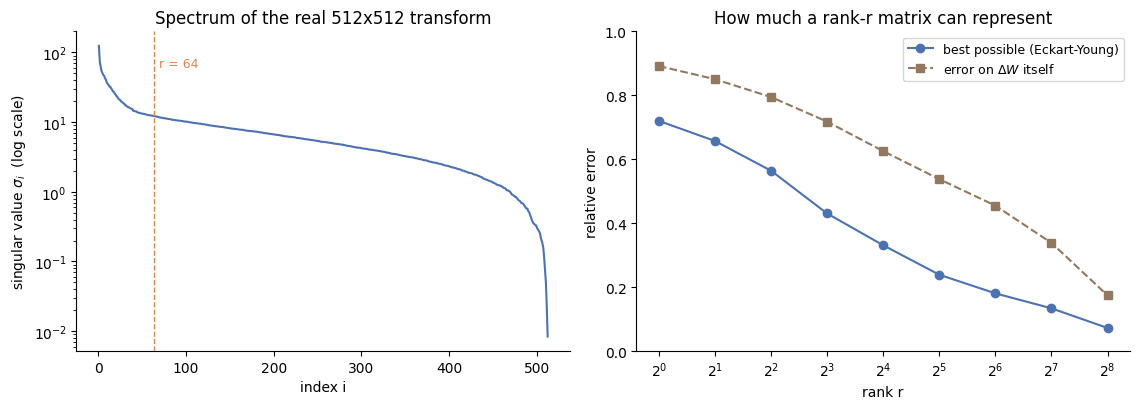

Read the left panel honestly: the spectrum falls steeply for the first few directions and then
decays slowly. This matrix is NOT secretly rank-2 - the best possible rank-8 approximation
still misses by 43.1%, and it takes rank 64 - a quarter of the dense parameter budget -
to get the held-out error down to 18.1%.


In [4]:
# WHAT: draw the spectrum and the Eckart-Young error curve side by side.
# WHY:  the shape of a spectrum is the single most informative picture in applied linear algebra.
#       A cliff means "low rank"; a slope means "you will have to choose a cut-off".
import matplotlib.pyplot as plt   # the notebook's inline backend renders the figure below the cell

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax1.semilogy(np.arange(1, D + 1), sigma, color="#4C72B0")
ax1.set_xlabel("index i"); ax1.set_ylabel(r"singular value $\sigma_i$  (log scale)")
ax1.set_title("Spectrum of the real 512x512 transform")
ax1.axvline(64, color="#DD8452", ls="--", lw=1)
ax1.text(70, sigma[0] * 0.5, "r = 64", color="#DD8452", fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

ax2.plot(floor["rank r"], floor["test error"], "o-", color="#4C72B0", label="best possible (Eckart-Young)")
ax2.plot(floor["rank r"], floor["matrix error"], "s--", color="#937860", label=r"error on $\Delta W$ itself")
ax2.set_xscale("log", base=2)
ax2.set_xlabel("rank r"); ax2.set_ylabel("relative error")
ax2.set_ylim(0, 1.0)
ax2.set_title("How much a rank-r matrix can represent")
ax2.legend(fontsize=9); ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

r64 = float(floor.loc[floor["rank r"] == 64, "test error"].iloc[0])
r8 = float(floor.loc[floor["rank r"] == 8, "test error"].iloc[0])
print("Read the left panel honestly: the spectrum falls steeply for the first few directions and then")
print(f"decays slowly. This matrix is NOT secretly rank-2 - the best possible rank-8 approximation")
print(f"still misses by {r8:.1%}, and it takes rank 64 - a quarter of the dense parameter budget -")
print(f"to get the held-out error down to {r64:.1%}.")

## Part 4: You never see `ΔW`. You see data.

Part 3 cheated. It computed the SVD of `ΔW` — but if you already had `ΔW`, you would not need to train anything.

Real adaptation gives you **examples**: pairs `(x, y)` where `y` is what the adapted model should produce. The optimizer must find `B` and `A` such that `x B A ≈ y − x W₀` for the pairs it has seen, and hope this generalises. That is a least-squares problem with a rank constraint, and it has a clean solver you can write in ten lines: **alternating least squares**. Hold `B` fixed and `A` is an ordinary least-squares solve; hold `A` fixed and `B` is another one. Repeat.

We initialise `B` with small random values, which is where LoRA itself uses randomness (`A` random, `B` zero in the paper's convention — we use the mirror image so the first solve is well-posed). This is weight initialisation, not fabricated data.

In [5]:
# WHAT: fit dW ~= B @ A from n observed (x, y) pairs using alternating least squares.
# WHY:  this is the honest version of "train a LoRA adapter". Each half of the alternation is the
#       normal-equations solve you met in Unit 1 lesson 04; the rank constraint is the only new idea.
RIDGE = 1e-4          # a whisker of Tikhonov regularisation so every solve is numerically safe


def fit_low_rank(X_train, Y_train, r, iters=15, seed=0):
    """Return (B, A) minimising ||X_train @ B @ A - Y_train||^2 with B: (D x r), A: (r x D)."""
    rg = np.random.default_rng(seed)
    B = rg.normal(0.0, 1.0 / np.sqrt(D), size=(D, r))     # weight init - the one legitimate use of RNG
    G = X_train.T @ X_train + RIDGE * np.eye(D)           # Gram matrix, reused every iteration
    C = X_train.T @ Y_train
    L = np.linalg.cholesky(G)                             # factor once, solve many times

    for _ in range(iters):
        # Step 1: with B frozen, Z = X B is an ordinary design matrix and A is a plain least squares fit.
        Z = X_train @ B
        A = np.linalg.solve(Z.T @ Z + RIDGE * np.eye(r), Z.T @ Y_train)
        # Step 2: with A frozen, the normal equations for B are (X'X) B (A A') = X'Y A'.
        B = np.linalg.solve(L.T, np.linalg.solve(L, C @ A.T)) @ np.linalg.inv(A @ A.T + 1e-10 * np.eye(r))
    return B, A


n_demo = 256
demo_idx = pool_idx[:n_demo]
X_demo, Y_demo = X[demo_idx], Y[demo_idx]

print(f"Fitting from {n_demo} real sections ({n_demo * D:,} scalar equations)\n")
print(" rank |  trainable | fitted from data | SVD truncation | difference")
beat = []
for r in [1, 2, 4, 8, 16, 32, 64]:
    B, A = fit_low_rank(X_demo, Y_demo, r)
    got = test_error(B @ A)
    svd = float(floor.loc[floor["rank r"] == r, "test error"].iloc[0])
    if got < svd:
        beat.append(r)
    print(f" {r:4d} | {r * 2 * D:10,} |           {got:.4f} |         {svd:.4f} | {got - svd:+.4f}")

print(f"\nranks where the fitted matrix BEATS the SVD truncation on this metric: "
      f"{beat if beat else 'none in this run'}")

Fitting from 256 real sections (131,072 scalar equations)

 rank |  trainable | fitted from data | SVD truncation | difference
    1 |      1,024 |           0.7186 |         0.7200 | -0.0014
    2 |      2,048 |           0.6587 |         0.6572 | +0.0015
    4 |      4,096 |           0.5712 |         0.5642 | +0.0071
    8 |      8,192 |           0.4473 |         0.4305 | +0.0168


   16 |     16,384 |           0.3557 |         0.3310 | +0.0246


   32 |     32,768 |           0.2868 |         0.2389 | +0.0479
   64 |     65,536 |           0.2452 |         0.1806 | +0.0645

ranks where the fitted matrix BEATS the SVD truncation on this metric: [1]


Two things in that table deserve a minute each.

**The fit tracks the truncation without ever seeing `ΔW`.** Read the `difference` column downwards. From 256 real sections the fit sits within a couple of hundredths of the SVD at the low ranks and falls further behind as the rank climbs — at rank 64 those 256 sections are being asked to determine 65,536 parameters, and it shows. The reassuring half of that: **the fitting procedure is not the bottleneck; the data is.**

**And nothing here forces the `difference` column to be positive.** The last line of the cell lists the ranks, if any, where the fitted matrix came out *ahead* of the truncation. That is not a violation of Eckart–Young, and understanding why is worth more than the rest of this part. The theorem minimises the distance to `ΔW` **itself** — the `matrix error` column of Part 3, which nothing can beat. The `test error` column measures something else entirely: how wrong the transform's *action on real documents* is, which weights each direction by how much our sections actually use it. Approximating an operator and approximating its effect on your data are two different optimisation problems, so a method that targets the second can land ahead of the truncation on it — most easily at low rank, where the two problems diverge most. Remember that the next time a compression method is described to you as "optimal" without the norm being named.

Which leaves the uncomfortable half. At rank 8 — the rank people copy from blog posts — even the SVD truncation leaves more than 40 % relative test error on this matrix; the exact figure is in the table above. If low rank were the whole story, LoRA would not work.

## 💬 Discuss

1. The `test error` column and the `matrix error` column in Part 3 disagree at every rank, and by a lot — compare the two at r = 8. Both are honest measurements of the same approximation. Which one would you put in front of a manager deciding whether to ship a rank-8 adapter, and what does the *other* number tell you that yours does not?
2. We chose `W₀ = I` so that the "base model" does nothing and all the difficulty sits in `ΔW`. Real pretrained weights are not the identity, and the update is *small* relative to them. Does that make the low-rank job easier or harder — and can you name the property of `W₀` your answer depends on?
3. Alternating least squares got close to the SVD truncation here from a random start, even though the rank constraint makes the joint problem non-convex. Gradient descent on a real Transformer has no such luck. Which feature of our problem — convexity in each factor separately, the size of the matrix, the amount of data, the absence of a non-linearity — do you think is doing the most work, and how would you test your guess with the code above?

## Part 5: The experiment — do the extra parameters buy anything?

Now the comparison that decides the question. Fix everything except one thing.

- **Baseline:** a *dense* update. Solve for all 262,144 numbers by least squares on `n` real examples. This is "full fine-tuning" of our one matrix.
- **Change exactly one thing:** constrain the update to rank *r*. Same data, same solver family, same held-out set.
- **Re-run** across `n ∈ {32, 64, 128, 256, 512, 1024}` and `r ∈ {1 … 128}`.

And measure one extra quantity that turns out to decide everything: `np.linalg.matrix_rank` of the dense solution itself.

In [6]:
# WHAT: sweep training-set size n against rank r; record held-out error and, crucially, the
#       measured rank of the unconstrained dense solution at each n.
# WHY:  the dense fit is the baseline LoRA has to beat. Its measured rank is the punchline.
N_VALUES = [32, 64, 128, 256, 512, 1024]
R_VALUES = [1, 2, 4, 8, 16, 32, 64, 128]

sweep = {}
print("    n | rank(dense) | dense test | " + " | ".join(f"r={r:<3d}" for r in R_VALUES))
print("-" * 96)
for n in N_VALUES:
    idx = pool_idx[:n]                                    # nested subsets: more data, same data
    Xn, Yn = X[idx], Y[idx]
    M_dense = np.linalg.lstsq(Xn, Yn, rcond=None)[0]      # minimum-norm least squares: no rank limit
    entry = {"dense": test_error(M_dense), "rank": int(np.linalg.matrix_rank(M_dense))}
    for r in R_VALUES:
        Bn, An = fit_low_rank(Xn, Yn, r)
        entry[r] = test_error(Bn @ An)
    sweep[n] = entry
    print(f" {n:4d} | {entry['rank']:11d} | {entry['dense']:10.4f} | " +
          " | ".join(f"{entry[r]:.4f}" for r in R_VALUES))

    n | rank(dense) | dense test | r=1   | r=2   | r=4   | r=8   | r=16  | r=32  | r=64  | r=128
------------------------------------------------------------------------------------------------


   32 |          32 |     0.6958 | 0.8136 | 0.7675 | 0.7360 | 0.7163 | 0.7027 | 0.6958 | 0.6953 | 0.6965


   64 |          64 |     0.5066 | 0.7516 | 0.7059 | 0.6382 | 0.5683 | 0.5332 | 0.5146 | 0.5067 | 0.5057


  128 |         128 |     0.3794 | 0.7305 | 0.6803 | 0.6107 | 0.5174 | 0.4413 | 0.4048 | 0.3875 | 0.3794


  256 |         255 |     0.2123 | 0.7186 | 0.6587 | 0.5712 | 0.4473 | 0.3557 | 0.2868 | 0.2452 | 0.2257


  512 |         496 |     0.0371 | 0.7146 | 0.6520 | 0.5611 | 0.4314 | 0.3279 | 0.2386 | 0.1737 | 0.1348


 1024 |         512 |     0.0000 | 0.7144 | 0.6509 | 0.5570 | 0.4279 | 0.3235 | 0.2324 | 0.1646 | 0.1239


Look at the `rank(dense)` column before the errors.

Read that column downwards: the measured rank of the unconstrained solution tracks *n* — 32 examples give a rank-32 update, 64 examples a rank-64 one, and so on, occasionally coming out one short where two real sections are nearly parallel. This is not a coincidence and not a numerical accident — it is a one-line consequence of what you learned in lesson 02: `X` has `n` rows, so its row space has dimension at most `n`, and a least-squares solution lives in that row space. **A dense update trained on `n` examples is already a rank-`n` update.** It just pays for 262,144 parameters to be one.

The pattern stops at n = 512 for the obvious reason — the matrix has only 512 columns, so the rank cannot exceed 512 however many sections you add. It reads slightly *below* 512 there, not exactly 512, because a handful of our real TF-IDF rows are close enough to linearly dependent that `matrix_rank` discounts them at its default tolerance. Real data does that; random data would not.

And watch the far end of the table, because it is the mirror image of the argument. By n = 1024 there are more independent examples than the matrix has columns, the dense fit recovers `ΔW` outright, and a rank-128 update is nowhere near it. LoRA is a bet on being on the *left* of that crossing — which, for a real fine-tuning set against a real weight matrix with millions of entries, you always are.

That reframes the entire LoRA question. You are not choosing between "low rank" and "full rank". You are choosing between an *explicit* rank you picked and an *implicit* rank your dataset picked for you.

In [7]:
# WHAT: state the head-to-head comparison in the smallest number of numbers that can carry it.
# WHY:  a sweep table is evidence; a decision needs one line. This is the line.
n = 64
dense_err = sweep[n]["dense"]
lora_err = sweep[n][64]
print(f"Adaptation set: {n} real sections\n")
print(f"  dense update  : {DENSE_PARAMS:>9,} trainable numbers | measured rank {sweep[n]['rank']:3d} "
      f"| held-out error {dense_err:.4f}")
print(f"  rank-64 update: {64 * 2 * D:>9,} trainable numbers | rank 64 by construction "
      f"| held-out error {lora_err:.4f}")
print(f"\n  -> {DENSE_PARAMS / (64 * 2 * D):.0f}x fewer parameters, error difference {abs(dense_err - lora_err):.6f}")
print("     The 196,608 parameters the dense fit carries beyond rank 64 changed nothing, and")
print("     the rank inequality above says they never could.\n")

# And the practical question: how far down the rank can you go before it does start to cost you?
n = 256
d = sweep[n]["dense"]
print(f"Adaptation set: {n} real sections. Doing nothing scores 1.0000; the dense fit scores {d:.4f}.")
print("\n rank | trainable | % of dense | test error | share of the dense fit's improvement")
for r in [4, 8, 16, 32, 64, 128]:
    e = sweep[n][r]
    share = (1 - e) / (1 - d)
    print(f" {r:4d} | {r * 2 * D:9,} | {r * 2 * D / DENSE_PARAMS:9.1%} |     {e:.4f} | {share:.1%}")

Adaptation set: 64 real sections

  dense update  :   262,144 trainable numbers | measured rank  64 | held-out error 0.5066
  rank-64 update:    65,536 trainable numbers | rank 64 by construction | held-out error 0.5067

  -> 4x fewer parameters, error difference 0.000018
     The 196,608 parameters the dense fit carries beyond rank 64 changed nothing, and
     the rank inequality above says they never could.

Adaptation set: 256 real sections. Doing nothing scores 1.0000; the dense fit scores 0.2123.

 rank | trainable | % of dense | test error | share of the dense fit's improvement
    4 |     4,096 |      1.6% |     0.5712 | 54.4%
    8 |     8,192 |      3.1% |     0.4473 | 70.2%
   16 |    16,384 |      6.2% |     0.3557 | 81.8%
   32 |    32,768 |     12.5% |     0.2868 | 90.5%
   64 |    65,536 |     25.0% |     0.2452 | 95.8%
  128 |   131,072 |     50.0% |     0.2257 | 98.3%


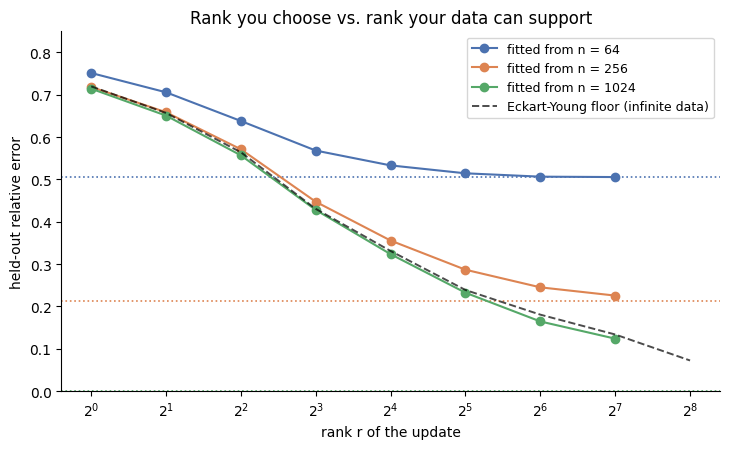

Dotted lines are the dense fit at the matching n. For each curve, the rank at which it catches
its own dotted line is the rank that n examples can actually support:

  n =   64: dense fit has measured rank  64 and error 0.5066; the rank-r curve catches it at r = 64
  n =  256: dense fit has measured rank 255 and error 0.2123; the rank-r curve catches it at nowhere in the plotted range (r <= 128)
  n = 1024: dense fit has measured rank 512 and error 0.0000; the rank-r curve catches it at nowhere in the plotted range (r <= 128)

A curve stops improving once r reaches the rank its data can support. Everything to the
right of that point is parameters you are paying for and cannot use.


In [8]:
# WHAT: plot held-out error against rank for three adaptation-set sizes, with the dense fit and the
#       Eckart-Young floor drawn in for reference.
# WHY:  one picture answers "which rank should I use?" - and shows that the answer moves with n.
fig, ax = plt.subplots(figsize=(7.4, 4.6))
colors = {64: "#4C72B0", 256: "#DD8452", 1024: "#55A868"}
for n, col in colors.items():
    ax.plot(R_VALUES, [sweep[n][r] for r in R_VALUES], "o-", color=col, label=f"fitted from n = {n}")
    ax.axhline(sweep[n]["dense"], color=col, ls=":", lw=1.2)
ax.plot(floor["rank r"], floor["test error"], "k--", lw=1.4, alpha=0.7,
        label="Eckart-Young floor (infinite data)")
ax.set_xscale("log", base=2)
ax.set_xlabel("rank r of the update"); ax.set_ylabel("held-out relative error")
ax.set_title("Rank you choose vs. rank your data can support")
ax.set_ylim(0, 0.85)
ax.legend(fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("Dotted lines are the dense fit at the matching n. For each curve, the rank at which it catches")
print("its own dotted line is the rank that n examples can actually support:\n")
for n in (64, 256, 1024):
    caught = [r for r in R_VALUES if sweep[n][r] <= sweep[n]["dense"] + 1e-3]
    where = f"r = {min(caught)}" if caught else f"nowhere in the plotted range (r <= {max(R_VALUES)})"
    print(f"  n = {n:4d}: dense fit has measured rank {sweep[n]['rank']:3d} and error "
          f"{sweep[n]['dense']:.4f}; the rank-r curve catches it at {where}")
print("\nA curve stops improving once r reaches the rank its data can support. Everything to the")
print("right of that point is parameters you are paying for and cannot use.")

## Part 6: What the LoRA paper actually reported — read only

Everything above ran on your machine. The following did not, and cannot: adapting GPT-3 175B needs a cluster and weights nobody can download in a classroom. It is quoted here so you can see the size of the effect the algebra above is buying, and it is **not** a result of this notebook.

| Quantity | Full fine-tuning of GPT-3 175B with Adam | LoRA |
|---|---|---|
| Trainable parameters | 175,000,000,000 | **10,000× fewer** (≈ 17.5 M) |
| GPU memory required | baseline | **3× less** |
| Quality on RoBERTa / DeBERTa / GPT-2 / GPT-3 | baseline | "on-par or better" |
| Extra inference latency | — | none (the adapter can be merged into `W₀`) |

*Source: the abstract of Hu et al., [arXiv:2106.09685](https://arxiv.org/abs/2106.09685). Read-only comparison; nothing in this table was measured here.*

The reason those numbers are so much friendlier than our error curve is the whole lesson of Part 5. A fine-tuning dataset is small — thousands of examples against hundreds of matrices with millions of entries each. The implicit rank of a full fine-tune under that much data scarcity is already low. LoRA's contribution is to *stop paying for the parameters that the data was never going to determine anyway*, and to say so in the architecture instead of leaving it to luck.

## ✅ Summary

**What you actually did here** (every number computed live above):

- Counted parameters: 262,144 for a dense 512×512 update, 1024·r for a rank-*r* one, break-even at r = 256
- Built a **real** 512×512 transform from this repository's own course text — PPMI over 512 terms, algebraic rank 512
- Used the SVD and the Eckart–Young theorem to compute the **floor**: the smallest distance to `ΔW` that any rank-*r* matrix can achieve
- Fitted `B A` from data alone with alternating least squares, tracked the SVD truncation closely, and found the two error metrics disagreeing at the low end of the rank range — for a reason worth knowing
- Measured `np.linalg.matrix_rank` of every unconstrained dense solution and watched it track the number of training examples, right up to where the matrix runs out of columns
- Showed one case where 4× fewer parameters produced a held-out error difference of less than one part in ten thousand

**The one sentence to keep:** rank is not something you discover in the weight matrix — it is something your *adaptation data* has already imposed, and LoRA's job is to stop paying for parameters the data could never have determined.

**Where this goes next:** in a Transformer the same `B A` is attached to the attention projection matrices instead of to one hand-built operator, `W₀` is a pretrained weight instead of the identity, and the least-squares solve is replaced by Adam on a non-convex loss. The parameter arithmetic, the spectrum, and the rank-of-the-data argument survive all three changes unchanged.

## ⚠️ Where this breaks

**Our target is a co-occurrence operator, not a Transformer weight update.** PPMI over course text is real data, but it is not the thing LoRA was designed for. Its spectrum decays slowly — it needed a rank of 64, a quarter of the dense parameter budget, before the held-out error fell below a fifth — while the *empirical* claim in Hu et al. is that useful updates inside a trained Transformer are far more concentrated than that. We have shown you the mathematics of low-rank adaptation on a real matrix. We have **not** shown you that Transformer updates are low-rank; that remains an empirical result you should read, not one this notebook demonstrates.

**Alternating least squares is friendlier than reality.** Each half-step here is convex and solved exactly, so a random start still lands close to the best rank-*r* matrix. Training a real adapter means gradient descent on a non-convex objective through a non-linearity, where initialisation, learning rate and scaling factor all matter and nothing guarantees you get near the best rank-*r* solution at all.

**"Same rank" is not "same matrix".** In Part 5 the dense fit at n = 64 and the rank-64 fit scored within one part in ten thousand of each other, which is a statement about *error*, not about the two matrices being equal — they span the same row space but need not be identical, and their singular vectors can differ. Shuttleworth, Andreas, Torralba and Sharma found exactly this kind of divergence in real models: "weight matrices trained with LoRA have new, high-ranking singular vectors, which we call *intruder dimensions*, while those trained with full fine-tuning do not" ([arXiv:2410.21228](https://arxiv.org/abs/2410.21228)) — matched task accuracy, different spectra.

**And the low-rank subspace can be the wrong subspace.** A 2025 result worth knowing: Zhu et al. found that reinforcement learning with verifiable rewards improves models by moving **off** the principal directions of the weight matrix — "minimal spectral drift", in contrast to supervised fine-tuning, which "targets principal weights" and distorts the spectrum ([arXiv:2511.08567](https://arxiv.org/abs/2511.08567)). A method that constrains updates to the top-*r* subspace is making an assumption about *which kind of learning* you are doing, and that assumption does not hold for every training regime.

**Finally, the numbers in this notebook are tied to this repository's text.** Edit the course quizzes, projects or case studies and the vocabulary, the PPMI matrix and every figure above shift. That is what it means for the data to be real: it is not frozen.

## 📚 References

Low-rank adaptation, what it costs, and what it assumes:

1. Eckart, C., & Young, G. (1936). *The Approximation of One Matrix by Another of Lower Rank*. Psychometrika, **1**(3), 211–218. [doi:10.1007/BF02288367](https://doi.org/10.1007/BF02288367) — the theorem that makes the truncated SVD the optimal rank-*r* approximation **in Frobenius norm**, and therefore the yardstick every fit in Part 4 is read against.
2. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., & Chen, W. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685) — the paper this notebook is a scale model of; source of every figure in the read-only table in Part 6.
3. Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023). *QLoRA: Efficient Finetuning of Quantized LLMs*. [arXiv:2305.14314](https://arxiv.org/abs/2305.14314) — the same factorisation over a 4-bit frozen base; how a 65B model becomes fine-tunable on a single 48 GB GPU.
4. Shuttleworth, R., Andreas, J., Torralba, A., & Sharma, P. (2024). *LoRA vs Full Fine-tuning: An Illusion of Equivalence*. [arXiv:2410.21228](https://arxiv.org/abs/2410.21228) — matched accuracy does not mean matched weights: the source of the *intruder dimensions* result quoted in "Where this breaks".
5. Zhu, H., Zhang, Z., Huang, H., Su, D., Liu, Z., Zhao, J., Fedorov, I., Pirsiavash, H., Sha, Z., Lee, J., Pan, D. Z., Wang, Z., Tian, Y., & Tai, K. S. (2025). *The Path Not Taken: RLVR Provably Learns Off the Principals*. [arXiv:2511.08567](https://arxiv.org/abs/2511.08567) — evidence that reinforcement-learning updates move off the principal directions, which is precisely the subspace a low-rank adapter is restricted to.